
Final Results:

Sphere: Best=0.0000, Mean=0.0000, Std=0.0000
Rastrigin: Best=0.9950, Mean=1.2935, Std=0.4559
Rosenbrock: Best=0.0167, Mean=0.3226, Std=0.1089
Ackley: Best=0.0000, Mean=0.0000, Std=0.0000


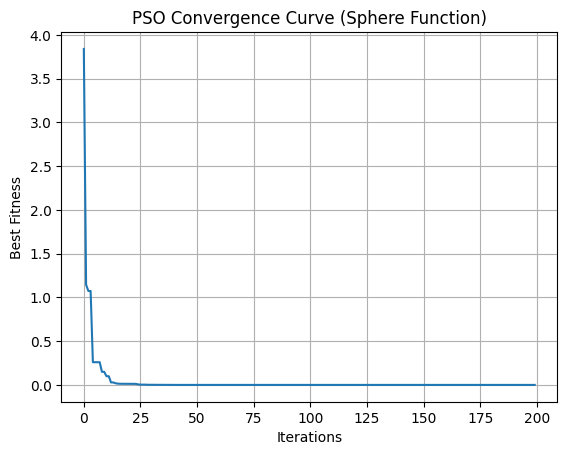

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return np.sum(x**2 - 10*np.cos(2*np.pi*x) + 10)

def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)

def ackley(x):
    n = len(x)
    return -20*np.exp(-0.2*np.sqrt(np.sum(x**2)/n)) - np.exp(np.sum(np.cos(2*np.pi*x))/n) + 20 + np.e


class PSO:
    def __init__(self, func, dim, bounds, particles=30, iterations=200,
                 w=0.7, c1=1.5, c2=1.5):

        self.func = func
        self.dim = dim
        self.lb, self.ub = bounds
        self.particles = particles
        self.iterations = iterations

        self.w = w
        self.c1 = c1
        self.c2 = c2

        self.history = []

    def optimize(self):
        X = np.random.uniform(self.lb, self.ub, (self.particles, self.dim))
        V = np.random.uniform(-1, 1, (self.particles, self.dim))

        Pbest = X.copy()
        Pbest_scores = np.array([self.func(x) for x in X])

        gbest_idx = np.argmin(Pbest_scores)
        Gbest = Pbest[gbest_idx].copy()
        Gbest_score = Pbest_scores[gbest_idx]

        for _ in range(self.iterations):
            for i in range(self.particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                V[i] = (self.w * V[i] +
                        self.c1 * r1 * (Pbest[i] - X[i]) +
                        self.c2 * r2 * (Gbest - X[i]))

                X[i] = X[i] + V[i]

                X[i] = np.clip(X[i], self.lb, self.ub)

                score = self.func(X[i])

                if score < Pbest_scores[i]:
                    Pbest[i] = X[i].copy()
                    Pbest_scores[i] = score

            best_idx = np.argmin(Pbest_scores)
            if Pbest_scores[best_idx] < Gbest_score:
                Gbest = Pbest[best_idx].copy()
                Gbest_score = Pbest_scores[best_idx]

            self.history.append(Gbest_score)

        return Gbest_score


def run_multiple(func, runs=10):
    results = []
    for _ in range(runs):
        pso = PSO(func, dim=5, bounds=(-5, 5), particles=30, iterations=200)
        best = pso.optimize()
        results.append(best)
    return np.min(results), np.mean(results), np.std(results)


functions = {
    "Sphere": sphere,
    "Rastrigin": rastrigin,
    "Rosenbrock": rosenbrock,
    "Ackley": ackley
}

final_results = {}

for name, func in functions.items():
    best, mean, std = run_multiple(func)
    final_results[name] = (best, mean, std)

print("\nFinal Results:\n")
for k, v in final_results.items():
    print(f"{k}: Best={v[0]:.4f}, Mean={v[1]:.4f}, Std={v[2]:.4f}")

pso = PSO(sphere, dim=5, bounds=(-5, 5), particles=30, iterations=200)
pso.optimize()

plt.plot(pso.history)
plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("PSO Convergence Curve (Sphere Function)")
plt.grid()
plt.show()